# Parametrized models: polynomials

Visualization of a simple case of a "parametrized model", $f_\theta (x)$, which changes with input $x$ but also with a change in parameters $\theta$. We use a polynomial as a simple example:
$$f_\theta(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$$

where $\theta = (\theta_0,\theta_1,\theta_2,\theta_3) $ is the vector of parameters (or **weights**).

Changing one parameter changes the whole curve.

- $\theta_0$: vertical offset
- $\theta_1$: linear contribution
- $\theta_2$: curvature
- $\theta_3$: asymmetry / cubic contribution

We will use a small dataset of points and try to find parameters that make the polynomial pass close to the points.

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Button, HBox, VBox, Output, HTML
from IPython.display import display, clear_output

plt.style.use("seaborn-v0_8-whitegrid")

# A small fixed dataset: deliberately not perfectly polynomial
rng = np.random.default_rng(7)
x_data = np.linspace(-2.5, 2.5, 13)
y_true = 1.0 - 0.7*x_data + 0.45*x_data**2 - 0.08*x_data**3
y_data = y_true + rng.normal(0, 0.35, size=len(x_data))

x_plot = np.linspace(x_data.min() - 0.2, x_data.max() + 0.2, 500)

def polynomial(x, theta):
    theta = np.asarray(theta)
    return sum(theta[k] * x**k for k in range(len(theta)))

def mse(theta):
    errors = polynomial(x_data, theta) - y_data
    return np.mean(errors**2)

print("Dataset ready:", len(x_data), "points")


Dataset ready: 13 points



## 2. Move the parameters and watch the model change

Each slider controls one parameter $\theta_i$.

1. Start with all parameters equal to zero.
2. Change **one parameter at a time**.
3. Observe how the entire curve changes.
4. Then try to make the curve pass through the cloud of points.

The number displayed below is the **mean squared error (MSE)**:

$
\mathcal L(\theta)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(f_\theta(x_i)-y_i\right)^2.
$

Your objective is to make this number as small as possible.


In [118]:
theta0 = FloatSlider(value=0.0, min=-5, max=5, step=0.05, description=r'$\theta_0$', continuous_update=True)
theta1 = FloatSlider(value=0.0, min=-5, max=5, step=0.05, description=r'$\theta_1$', continuous_update=True)
theta2 = FloatSlider(value=0.0, min=-3, max=3, step=0.05, description=r'$\theta_2$', continuous_update=True)
theta3 = FloatSlider(value=0.0, min=-1.5, max=1.5, step=0.02, description=r'$\theta_3$', continuous_update=True)

out = Output()

def update(theta_0, theta_1, theta_2, theta_3):
    theta = [theta_0, theta_1, theta_2, theta_3]
    y_plot = polynomial(x_plot, theta)
    loss = mse(theta)

    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(x_data, y_data, s=55, label="data", zorder=3)
        ax.plot(x_plot, y_plot, linewidth=2.5, label=r"$f_\theta(x)$")
        ax.axhline(0, linewidth=0.8)
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        ax.set_ylim([0,10])
        ax.set_title("Polynomial model")
        ax.legend()
        plt.show()

        print(f"Parameters θ = [{theta_0:.2f}, {theta_1:.2f}, {theta_2:.2f}, {theta_3:.2f}]")
        print(f"Mean squared error  L(θ) = {loss:.4f}")

controls = VBox([theta0, theta1, theta2, theta3])
ui = HBox([controls, out])
display(ui)

for s in [theta0, theta1, theta2, theta3]:
    s.observe(lambda change: update(theta0.value, theta1.value, theta2.value, theta3.value), names="value")

update(theta0.value, theta1.value, theta2.value, theta3.value)


In [70]:
mintheta = -2.
maxtheta = 2.
range_theta = np.linspace(mintheta,maxtheta,num=201)
mses = np.empty((201,201))
mses_dict = {}
for i,theta1 in enumerate(range_theta):
    for j,theta2 in enumerate(range_theta):
        theta = [1., theta1, theta2, 0]
        mses[i,j] = mse(theta)
        mses_dict[(i,j)] = mses[i,j]

In [94]:
mini, minj = np.where(mses == mses.min())
mini, minj

(array([49]), array([123]))

In [95]:
mses.min(), mses.mean(), mses.max()

(np.float64(0.1250732633319939),
 np.float64(22.270979272857712),
 np.float64(85.68921831596505))

In [112]:
print("hey", "yo", "ha")

hey yo ha


In [115]:
print(f"minimum at theta_1={range_theta[mini]}, theta_2={range_theta[minj]}")

minimum at theta_1=[-1.02], theta_2=[0.46]


In [92]:
mse([1,0.46, -1.02, 0]), mse([1, -1.02, 0.46, 0])

(np.float64(28.29788741346189), np.float64(0.12507326333199387))

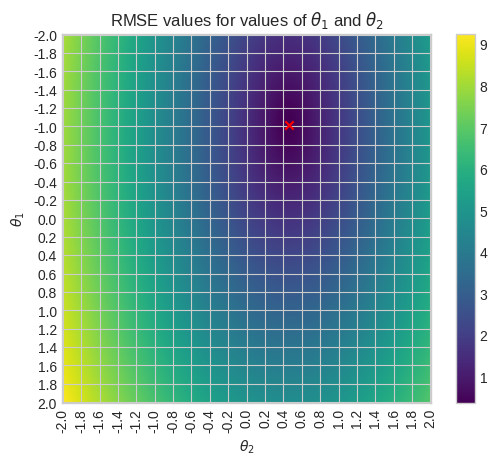

In [120]:
plt.imshow(np.sqrt(mses), cmap="viridis")
plt.xticks(np.arange(21)*10, np.round(range_theta[::10], 2), rotation=90)
plt.ylabel(r"$\theta_1$")
plt.xlabel(r"$\theta_2$")
plt.title(r"RMSE values for values of $\theta_1$ and $\theta_2$")
plt.yticks(np.arange(21)*10, np.round(range_theta[::10], 2))
plt.colorbar()
plt.scatter(minj, mini, color="red", marker="x")
plt.savefig("loss_landscape_polynomial.pdf")
plt.show()